## Importing Libraries

In [171]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## Read data

In [172]:
data = pd.read_csv("/workspaces/Elevvo_Internship_Tasks/Data/loan_approval_dataset.csv")
data.head(10)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [173]:
# Removing load_id since it does provide useful information
data = data.drop('loan_id', axis=1)
data.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [174]:
# make all column names lowercase and replace spaces with underscores
data.columns = data.columns.str.lower().str.replace(" ", "_")

print(data.columns)  # now you’ll see: ['loan_status', 'education', ...]

Index(['_no_of_dependents', '_education', '_self_employed', '_income_annum',
       '_loan_amount', '_loan_term', '_cibil_score',
       '_residential_assets_value', '_commercial_assets_value',
       '_luxury_assets_value', '_bank_asset_value', '_loan_status'],
      dtype='object')


In [175]:
#Checking datatypes of columns
data.dtypes

_no_of_dependents             int64
_education                   object
_self_employed               object
_income_annum                 int64
_loan_amount                  int64
_loan_term                    int64
_cibil_score                  int64
_residential_assets_value     int64
_commercial_assets_value      int64
_luxury_assets_value          int64
_bank_asset_value             int64
_loan_status                 object
dtype: object

In [176]:
#checking for missing or null values
#data.isna().sum()
print("\n🔍 Number of Missing values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")


🔍 Number of Missing values:
No missing values found!


In [177]:
#checking the shape of the data
data.shape

(4269, 12)

In [178]:
# Descriptive statistics of our dataset
data.describe()

,_no_of_dependents,_income_annum,_loan_amount,_loan_term,_cibil_score,_residential_assets_value,_commercial_assets_value,_luxury_assets_value,_bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Data Exploration and Visualization

In [179]:
# Loan status distribution
fig_loan_status= px.histogram(data,x='_loan_status',title='Loan Status Distribution')
fig_loan_status.show()

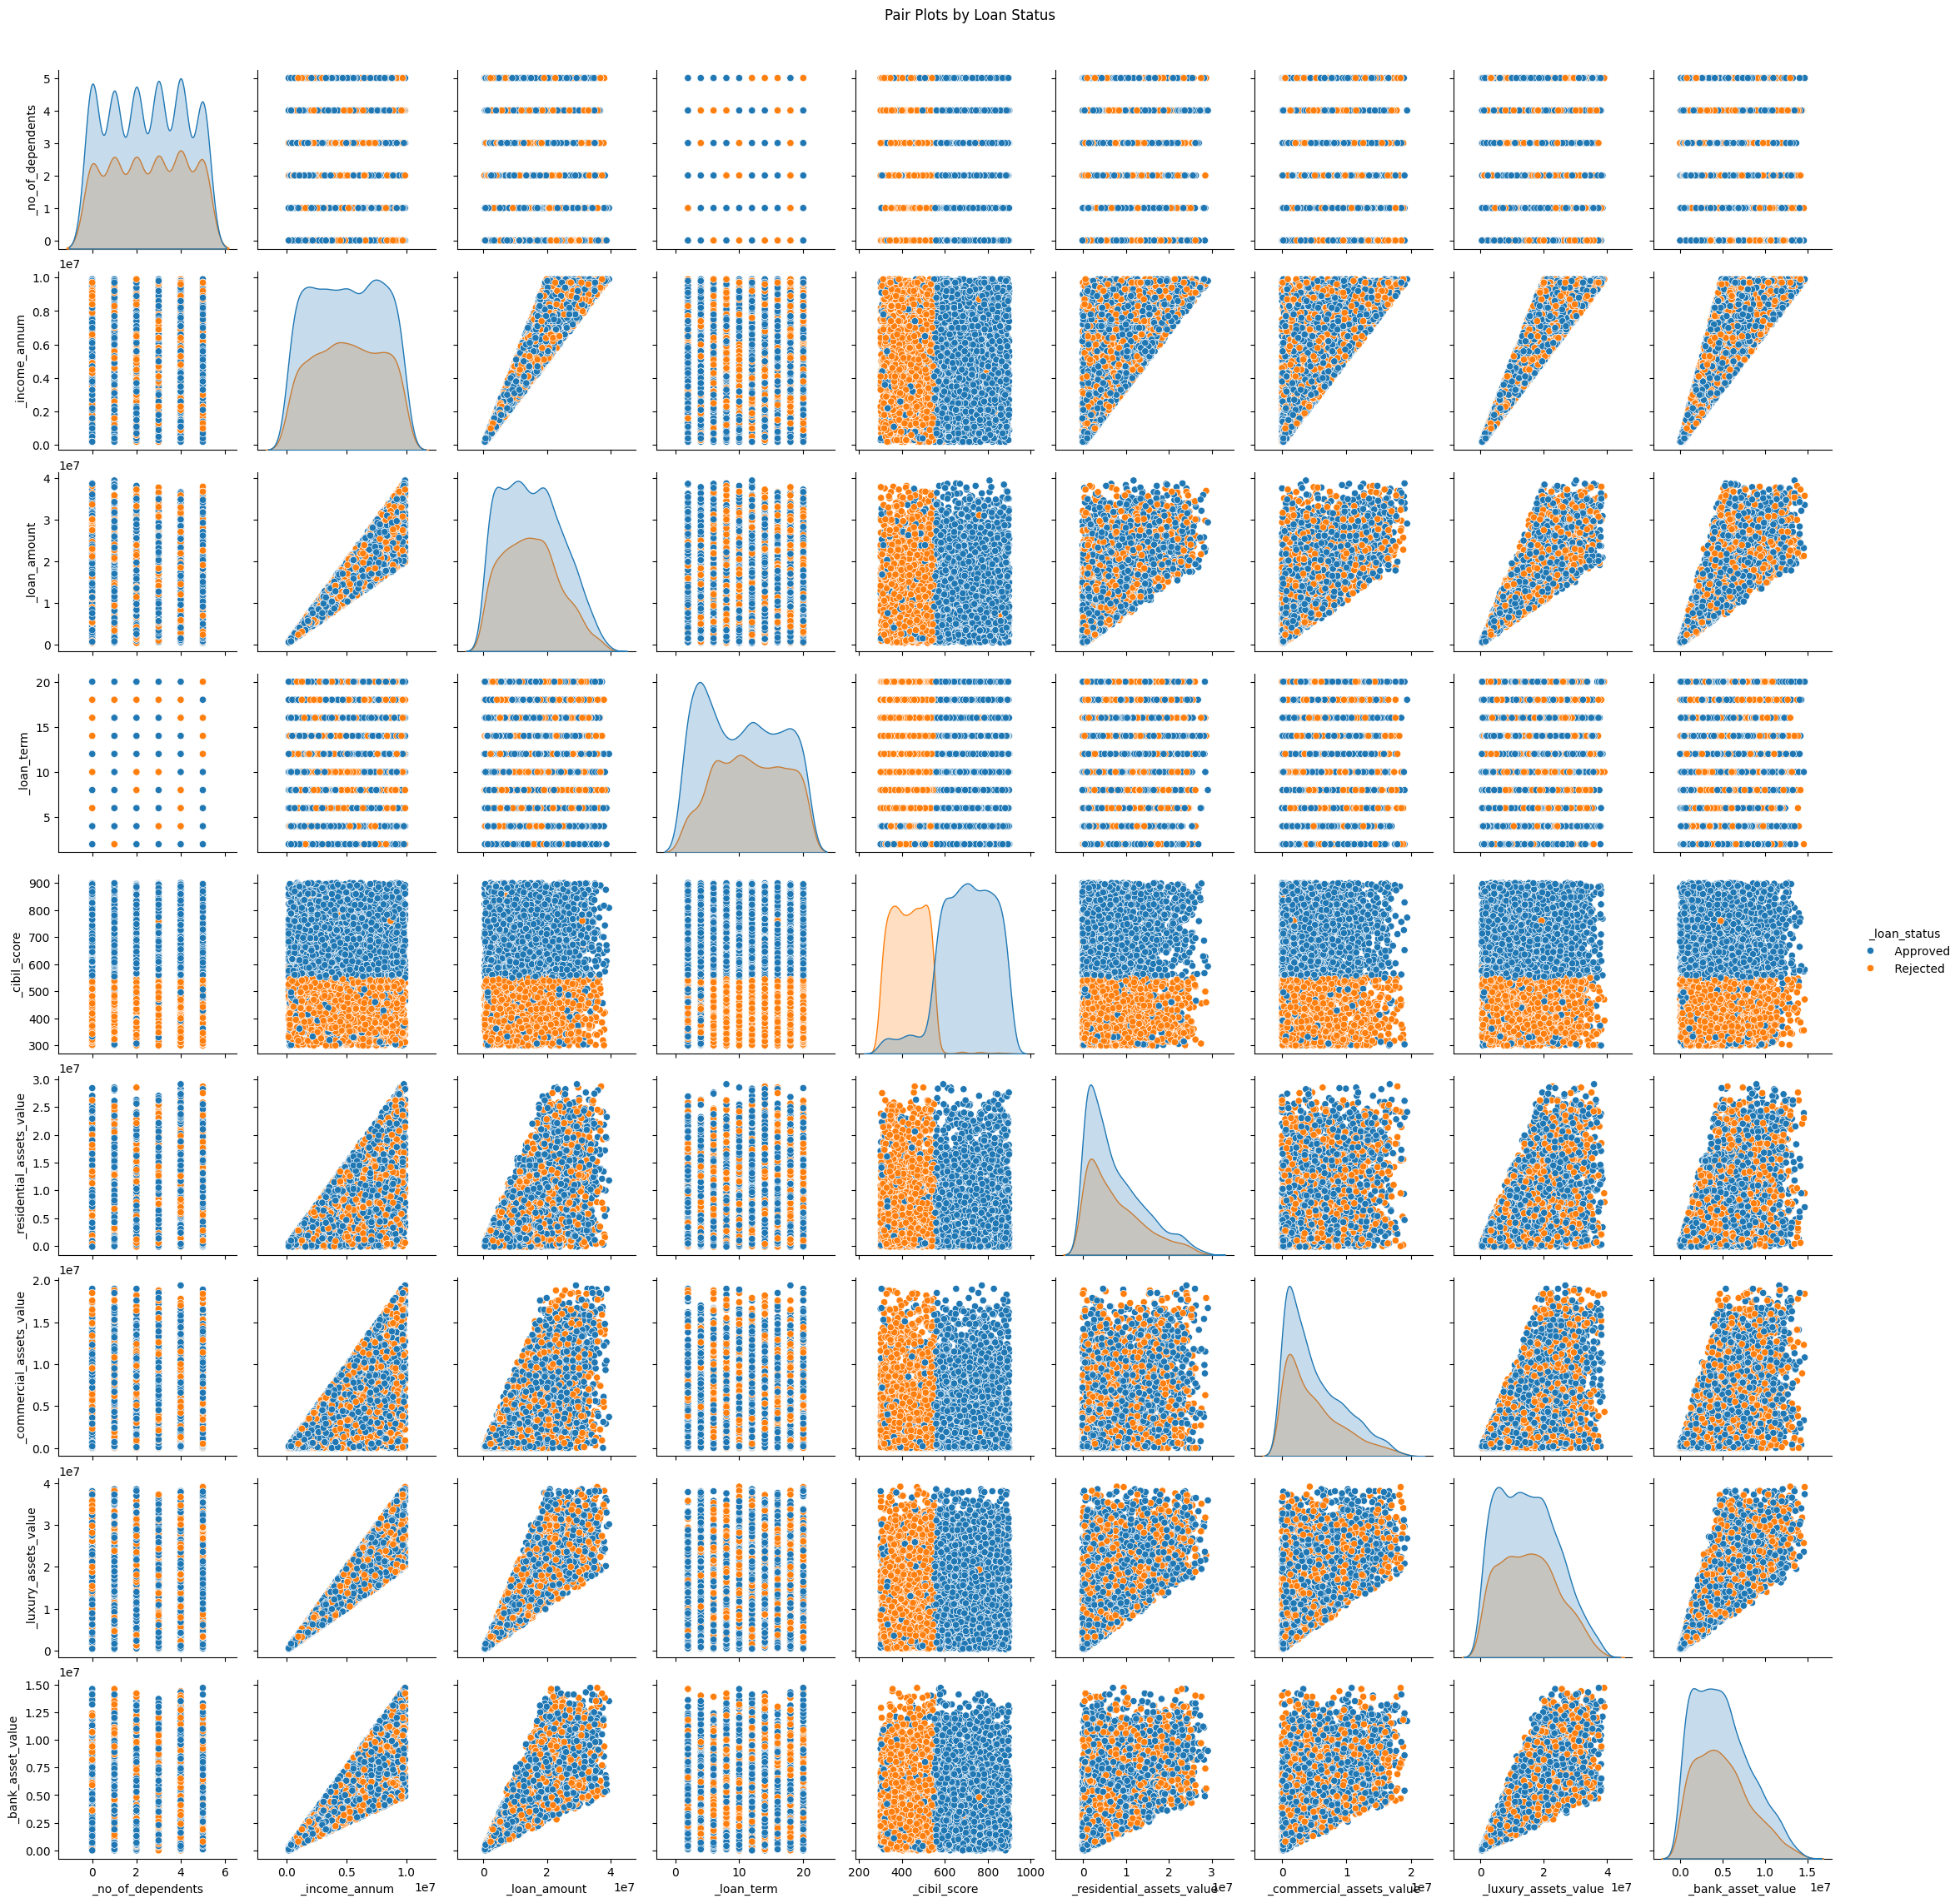

In [180]:
# Pair Plots by Loan Status

sns.pairplot(data, hue='_loan_status')
plt.suptitle('Pair Plots by Loan Status', y=1.02)
plt.show()

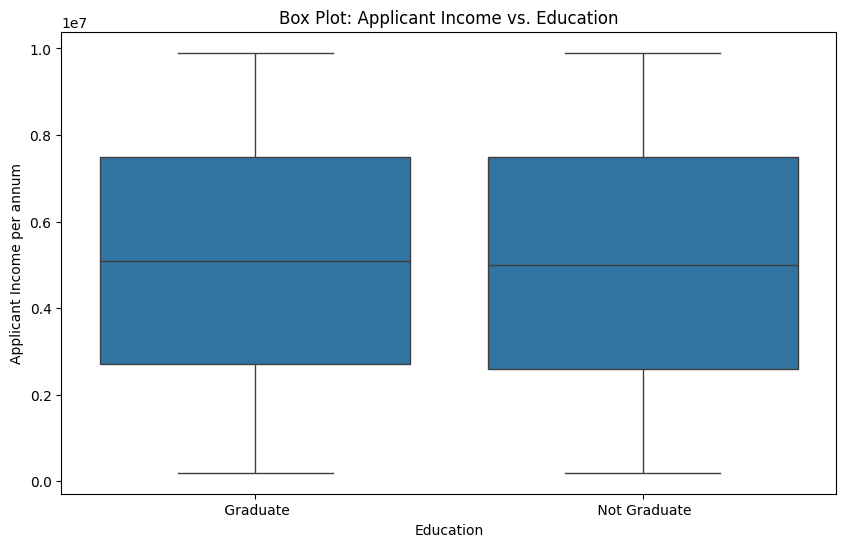

In [181]:
# Applicant Income vs. Education

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='_education', y='_income_annum')
plt.ylabel('Applicant Income per annum')
plt.xlabel('Education')
plt.title('Box Plot: Applicant Income vs. Education')
plt.show()

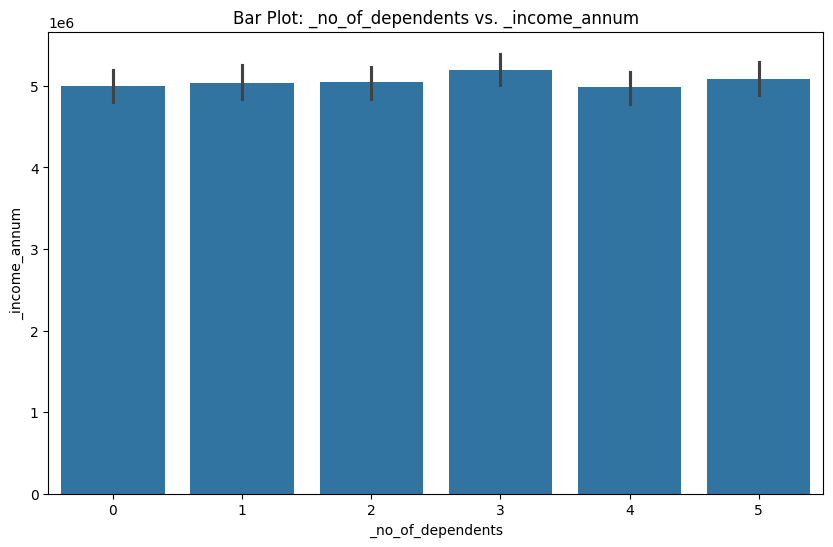

In [182]:
# Number of independents vs Income per annum

plt.figure(figsize=(10,6))
sns.barplot(data, x='_no_of_dependents', y='_income_annum')
plt.xlabel('_no_of_dependents')
plt.ylabel('_income_annum')
plt.title('Bar Plot: _no_of_dependents vs. _income_annum')
plt.show()

## Data Preparation

In [183]:
#Convert categorical Columns into numerical ones
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

col_to_encode = ['_education', '_self_employed', '_loan_status']
for i in col_to_encode:
    data[i] = le.fit_transform(data[i])


In [184]:
data.head()

,_no_of_dependents,_education,_self_employed,_income_annum,_loan_amount,_loan_term,_cibil_score,_residential_assets_value,_commercial_assets_value,_luxury_assets_value,_bank_asset_value,_loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [185]:
# Scale the numerical columns using StandardScaler
scaler = StandardScaler()
numerical_cols = ['_income_annum', '_loan_amount', '_residential_assets_value', '_commercial_assets_value', '_luxury_assets_value','_bank_asset_value']
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
data[numerical_cols] = scaler.transform(data[numerical_cols])

In [186]:
data.head()

,_no_of_dependents,_education,_self_employed,_income_annum,_loan_amount,_loan_term,_cibil_score,_residential_assets_value,_commercial_assets_value,_luxury_assets_value,_bank_asset_value,_loan_status
0,2,0,0,-1.802638,-1.673628,12,778,-1.149125,-1.133236,-1.661741,-1.531382,0
1,0,1,1,-1.802638,-1.673628,8,417,-1.149125,-1.133237,-1.661741,-1.531382,1
2,3,0,0,-1.802638,-1.673628,20,506,-1.149125,-1.133237,-1.661740,-1.531381,1
3,3,0,0,-1.802638,-1.673628,8,467,-1.149125,-1.133237,-1.661741,-1.531382,1
4,5,1,1,-1.802638,-1.673628,20,382,-1.149125,-1.133237,-1.661741,-1.531382,1


In [187]:
# Split the dataset into features (X) and target (y)
X = data.drop('_loan_status', axis=1)
y = data['_loan_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Evaluating models without SMOTE

print("🎯 BASELINE MODELS (Without SMOTE)")
print("=" * 40)
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
classification_report_log = classification_report(y_test, y_pred_log)
confusion_matrix_log = confusion_matrix(y_test, y_pred_log)
print("\nLogistic Regression:")
print("Accuracy:", accuracy_log)
print("Classification Report:\n", classification_report_log)
print("Confusion Matrix:\n", confusion_matrix_log)
print("\n")

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
classification_report_rf = classification_report(y_test, y_pred_rf)
confusion_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nRandom Forest Classifier:")
print("Accuracy:", accuracy_rf)
print("Classification Report:\n", classification_report_rf)
print("Confusion Matrix:\n", confusion_matrix_rf)
print("\n")

svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
classification_report_svc = classification_report(y_test, y_pred_svc)
confusion_matrix_svc = confusion_matrix(y_test, y_pred_svc)
print("\nSVC:")
print("Accuracy: ", accuracy_svc)
print("\nClassification Report: ", classification_report_svc)
print("\nConfusion Matrix: \n", confusion_matrix_svc)


clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_clf = clf.predict(X_test)
accuracy_clf = accuracy_score(y_test, y_pred_clf)
classification_report_clf = classification_report(y_test, y_pred_clf)
confusion_matrix_clf = confusion_matrix(y_test, y_pred_clf)
print("\nDecision Tree:")
print("Accuracy: ", accuracy_clf)
print("\nClassification Report: ", classification_report_clf)
print("\nConfusion Matrix: \n", confusion_matrix_clf)


🎯 BASELINE MODELS (Without SMOTE)

Logistic Regression:
Accuracy: 0.9121779859484778
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       536
           1       0.89      0.88      0.88       318

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854

Confusion Matrix:
 [[500  36]
 [ 39 279]]



Random Forest Classifier:
Accuracy: 0.9718969555035128
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.98      0.95      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Confusion Matrix:
 [[529   7]
 [ 17 301]]



SVC:
Accuracy:  0.9543325526932084

Classification Report:          

In [194]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: _loan_status
0    2120
1    1295
Name: count, dtype: int64
After SMOTE: _loan_status
0    2120
1    2120
Name: count, dtype: int64


In [196]:
# Evaluating models with SMOTE

print("🎯 BASELINE MODELS (SMOTE)")
print("=" * 40)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_res, y_train_res)
y_pred_log_smote = log_model.predict(X_test)
accuracy_log_smote = accuracy_score(y_test, y_pred_log_smote)
classification_report_log_smote = classification_report(y_test, y_pred_log_smote)
confusion_matrix_log_smote = confusion_matrix(y_test, y_pred_log_smote)
print("\nLogistic Regression:")
print("Accuracy:", accuracy_log_smote)
print("Classification Report:\n", classification_report_log_smote)
print("Confusion Matrix:\n", confusion_matrix_log_smote)
print("\n")


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf_smote = rf_model.predict(X_test)
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
classification_report_rf_smote = classification_report(y_test, y_pred_rf_smote)
confusion_matrix_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
print("\nRandom Forest:")
print("Accuracy:", accuracy_rf_smote)
print("Classification Report:\n", classification_report_rf_smote)
print("Confusion Matrix:\n", confusion_matrix_rf_smote)
print("\n")



svc_model = SVC(random_state=42)
svc_model.fit(X_train_res, y_train_res)
y_pred_svc_smote = svc_model.predict(X_test)
accuracy_svc_smote = accuracy_score(y_test, y_pred_svc_smote)
classification_report_svc_smote = classification_report(y_test, y_pred_svc_smote)
confusion_matrix_svc_smote = confusion_matrix(y_test, y_pred_svc_smote)
print("\nSVM :")
print("Accuracy:", accuracy_svc_smote)
print("Classification Report:\n", classification_report_svc_smote)
print("Confusion Matrix:\n", confusion_matrix_svc_smote)
print("\n")


clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_res, y_train_res)
y_pred_clf_smote = clf.predict(X_test)
accuracy_clf_smote = accuracy_score(y_test, y_pred_clf_smote)
classification_report_clf_smote = classification_report(y_test, y_pred_clf_smote)
confusion_matrix_clf_smote = confusion_matrix(y_test, y_pred_clf_smote)
print("\nDecision Tree:")
print("Accuracy: ", accuracy_clf_smote)
print("\nClassification Report: ", classification_report_clf_smote)
print("\nConfusion Matrix: \n", confusion_matrix_clf_smote)



🎯 BASELINE MODELS (SMOTE)

Logistic Regression:
Accuracy: 0.914519906323185
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       536
           1       0.85      0.93      0.89       318

    accuracy                           0.91       854
   macro avg       0.90      0.92      0.91       854
weighted avg       0.92      0.91      0.92       854

Confusion Matrix:
 [[485  51]
 [ 22 296]]



Random Forest:
Accuracy: 0.9660421545667447
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       536
           1       0.96      0.94      0.95       318

    accuracy                           0.97       854
   macro avg       0.97      0.96      0.96       854
weighted avg       0.97      0.97      0.97       854

Confusion Matrix:
 [[525  11]
 [ 18 300]]



SVM :
Accuracy: 0.9227166276346604
Classification Report:
               precision    re

## Hyperparameter tuning

In [135]:
from sklearn.model_selection import GridSearchCV

log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

log_reg_params = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

log_reg_grid = GridSearchCV(log_reg_model, param_grid=log_reg_params, cv=3)

log_reg_grid.fit(X_train, y_train)

log_reg_best = log_reg_grid.best_estimator_

y_pred_log_reg = log_reg_best.predict(X_test)

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print("Logistic Regression:")
print(f"Best parameters: {log_reg_grid.best_params_}")
print(f"Best Cross-Validation Score: {log_reg_grid.best_score_}")
print(f"Accuracy: {accuracy_log_reg}")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression:
Best parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'newton-cg'}
Best Cross-Validation Score: 0.92006009444147
Accuracy: 0.9133489461358314
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       536
           1       0.88      0.88      0.88       318

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854

Confusion Matrix:
[[499  37]
 [ 37 281]]


 Model comparison

📊 Accuracy Comparison of Models:
****************************************
Data                 Baseline     SMOTE
Model                                  
Decision Tree        0.964871  0.957845
Logistic Regression  0.912178  0.914520
Random Forest        0.971897  0.966042
SVC                  0.954333  0.922717


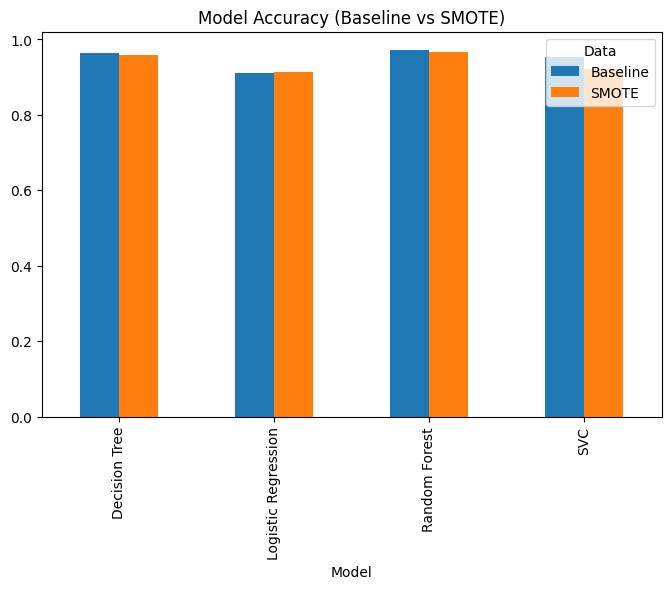

In [198]:
print(" Model comparison")

# Store results
results = []

# Baseline models
results.append(["Logistic Regression", "Baseline", accuracy_score(y_test, y_pred_log)])
results.append(["Random Forest", "Baseline", accuracy_score(y_test, y_pred_rf)])
results.append(["SVC", "Baseline", accuracy_score(y_test, y_pred_svc)])
results.append(["Decision Tree", "Baseline", accuracy_score(y_test, y_pred_clf)])

# SMOTE models
results.append(["Logistic Regression", "SMOTE", accuracy_score(y_test, y_pred_log_smote)])
results.append(["Random Forest", "SMOTE", accuracy_score(y_test, y_pred_rf_smote)])
results.append(["SVC", "SMOTE", accuracy_score(y_test, y_pred_svc_smote)])
results.append(["Decision Tree", "SMOTE", accuracy_score(y_test, y_pred_clf_smote)])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Data", "Accuracy"])

# Pivot for nice comparison
comparison_table = results_df.pivot(index="Model", columns="Data", values="Accuracy")

print("\n📊 Accuracy Comparison of Models:")
print("*" * 40)
print(comparison_table)

# Optional: Display as bar chart
comparison_table.plot(kind="bar", figsize=(8,5), title="Model Accuracy (Baseline vs SMOTE)");